In [1]:
import torch
import numpy as np
import tensorly
from tensorly.tenalg import multi_mode_dot
from tensorly.decomposition import parafac, randomised_parafac
tensorly.set_backend('pytorch')
import matplotlib.pyplot as plt

In [2]:
def reconstruct_from_factors(factors: list[torch.Tensor]) -> torch.Tensor:
    
    if not factors:
        return torch.tensor([])
        
    #use einstein summation notation
    indices = [chr(97 + i) for i in range(len(factors))] 
    einsum_str = f"{','.join(indices)}->{''.join(indices)}"
    
    return torch.einsum(einsum_str, *factors)

def als_rank_one_approximation(B: torch.Tensor, max_iter: int = 10000, tol: float = 1e-8) -> list[torch.Tensor]:

    d = B.dim()
    dims = B.shape

    x_list = [torch.rand(dim) for dim in dims]
    
    # Normalisation
    for k in range(d):
        norm_val = torch.norm(x_list[k])
        if norm_val > 0:
            x_list[k] /= norm_val

    for _ in range(max_iter):
        x_list_old = [x.clone() for x in x_list]

        for k in range(d):
            
            # Solution of least squere problem is a tesordot of B and all vectors from x_list 
            update_vec = B
            modes_to_contract = sorted([m for m in range(d) if m != k], reverse=True)
            for mode in modes_to_contract:
                update_vec = torch.tensordot(update_vec, x_list[mode], dims=([mode], [0]))

            norm_val = torch.norm(update_vec)
            if norm_val > 0:
                x_list[k] = update_vec / norm_val
            else:
                x_list[k] = update_vec

        # max_change = max(torch.norm(x_list[k] - x_list_old[k]).item() for k in range(d))
        # if max_change < tol:
        #     break


    reconstruct_norm = reconstruct_from_factors(x_list)
    x_list[0] = torch.tensordot(B, reconstruct_norm, dims=B.dim()) * x_list[0]
    return x_list

In [3]:
#Test ALS
A = torch.rand(10) 
B = torch.arange(1, 4) 
C = torch.arange(1, 5) 
original_tensor = torch.einsum('i,j,k->ijk', A, B, C)
print(original_tensor)


reconstructed = reconstruct_from_factors(als_rank_one_approximation(original_tensor))
print(reconstructed)
torch.norm(original_tensor - reconstructed)


tensor([[[8.7717e-01, 1.7543e+00, 2.6315e+00, 3.5087e+00],
         [1.7543e+00, 3.5087e+00, 5.2630e+00, 7.0173e+00],
         [2.6315e+00, 5.2630e+00, 7.8945e+00, 1.0526e+01]],

        [[6.4523e-01, 1.2905e+00, 1.9357e+00, 2.5809e+00],
         [1.2905e+00, 2.5809e+00, 3.8714e+00, 5.1619e+00],
         [1.9357e+00, 3.8714e+00, 5.8071e+00, 7.7428e+00]],

        [[8.8470e-01, 1.7694e+00, 2.6541e+00, 3.5388e+00],
         [1.7694e+00, 3.5388e+00, 5.3082e+00, 7.0776e+00],
         [2.6541e+00, 5.3082e+00, 7.9623e+00, 1.0616e+01]],

        [[3.2306e-01, 6.4612e-01, 9.6918e-01, 1.2922e+00],
         [6.4612e-01, 1.2922e+00, 1.9384e+00, 2.5845e+00],
         [9.6918e-01, 1.9384e+00, 2.9075e+00, 3.8767e+00]],

        [[3.6347e-01, 7.2694e-01, 1.0904e+00, 1.4539e+00],
         [7.2694e-01, 1.4539e+00, 2.1808e+00, 2.9078e+00],
         [1.0904e+00, 2.1808e+00, 3.2712e+00, 4.3617e+00]],

        [[4.1625e-01, 8.3250e-01, 1.2488e+00, 1.6650e+00],
         [8.3250e-01, 1.6650e+00, 2.4975e+00, 

tensor(3.6751e-06)

In [4]:
def gta( B: torch.Tensor, 
        error_tol: float = 1e-4, 
        max_rank: int = 50, 
        max_iter_als: int = 100, 
        tol_als: float = 1e-8
        ) -> tuple[list[torch.Tensor], torch.Tensor, int]:
    
    d = B.dim()
    norm_B = torch.norm(B)
    U = [torch.empty((B.shape[i], 0)) for i in range(d)]
    T = torch.zeros(B.shape)
    
    current_rank = 0
    current_error = 1.0 
    errors = []
    flag = 0
    while current_rank < max_rank:
        current_rank += 1
        
        x_list = als_rank_one_approximation(B - T, max_iter=max_iter_als, tol=tol_als)
        
        for j in range(d):
            new_vec = x_list[j]
            if U[j].shape[1] > 0:
                proj = torch.matmul(U[j], torch.matmul(U[j].T, new_vec))
                orth_vec = new_vec - proj
            else:
                orth_vec = new_vec
            norm = torch.norm(orth_vec)
            
            if norm > 1e-8:
                orth_vec /= norm
                U[j] = torch.cat([U[j], orth_vec.unsqueeze(1)], dim=1)

        if all(u.shape[1] > 0 for u in U):
            core_tensor = multi_mode_dot(B, [u.T for u in U])
            T = multi_mode_dot(core_tensor, U)
        
        
        current_error = torch.norm(B - T) / norm_B
        errors.append(current_error)

        # if current_error > 1 and flag == 0:
        #     print(f"rank {current_rank} - first time error > 1")
        #     flag = 1
        if current_error < error_tol:
            break

    return U, core_tensor, current_rank, errors

In [5]:
def generate_low_tucker_rank_tensor(
    shape: tuple[int, ...], 
    rank: tuple[int, ...], 
    device=None
) -> tuple[torch.Tensor, torch.Tensor, list[torch.Tensor]]:
    """
    Генерирует тензор с заданным рангом Такера.

    Аргументы:
        shape (tuple): Желаемая форма выходного тензора (например, (20, 30, 40)).
        rank (tuple): Желаемый ранг Такера (например, (5, 6, 7)).
        device: Устройство для создания тензора ('cpu' или 'cuda').

    Возвращает:
        tuple:
            - Сгенерированный тензор низкого ранга.
            - Истинное ядро, использованное для генерации.
            - Список истинных фактор-матриц, использованных для генерации.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Генерируем случайные ортонормированные фактор-матрицы
    # Столбцы каждой матрицы U_i будут ортонормированным базисом
    factor_matrices = []
    for s, r in zip(shape, rank):
        # Создаем случайную матрицу и получаем ее ортонормированный базис через QR-разложение
        # Это гарантирует, что U.T @ U будет единичной матрицей
        q, _ = torch.linalg.qr(torch.randn(s, r, device=device))
        factor_matrices.append(q)
        
    # 2. Генерируем случайное ядро (core tensor)
    core_tensor = torch.randn(*rank, device=device)
    
    # 3. Собираем полный тензор через мульти-тензорное произведение
    low_rank_tensor = multi_mode_dot(core_tensor, factor_matrices)
    
    return low_rank_tensor, core_tensor, factor_matrices


# Тестирование алгоритма для тензоров

1. Тензор с ядром одинаковых размеров по всем размерностям

Размеры матриц:
  U[0]: torch.Size([90, 30])
  U[1]: torch.Size([105, 30])
  U[2]: torch.Size([100, 30])
Размер ядра: torch.Size([30, 30, 30])
Итоговая ошибка: 0.000007


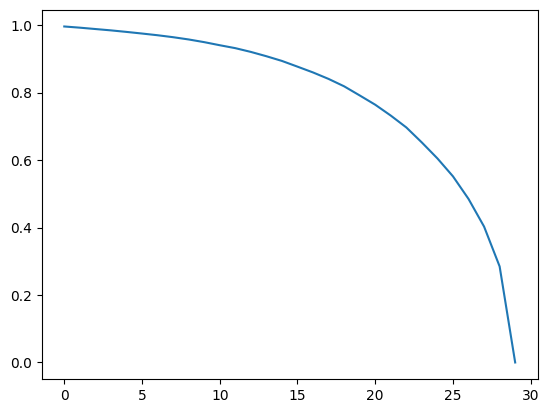

In [6]:
tensor_shape = (90, 105, 100)
tucker_rank = (30, 30, 30)
B, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

factor_matrices, core_tensor, final_rank, errors = gta(B, max_rank=100, max_iter_als=100, error_tol=0.01)


print("Размеры матриц:")
for i, u_matrix in enumerate(factor_matrices):
    print(f"  U[{i}]: {u_matrix.shape}")
print(f"Размер ядра: {core_tensor.shape}")

reconstructed_B = multi_mode_dot(core_tensor, factor_matrices)
final_error_check = torch.norm(B - reconstructed_B) / torch.norm(B)
print(f"Итоговая ошибка: {final_error_check.item():.6f}")


x = list(range(0, len(errors[:40])))
plt.plot(x, errors[:40])
plt.show()

In [7]:
tensor_shape = (500, 100, 105, 100)
tucker_rank = (15, 8, 80, 30)
B, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)
factors = randomised_parafac(B, rank=100, tol=1e-3, n_samples = 10000)

In [8]:
for factor in factors[1]:
    print(torch.tensor(factor).shape)
    # print(factor)
    print(torch.linalg.matrix_rank(factor))

torch.Size([500, 100])
tensor(15)
torch.Size([100, 100])
tensor(8)
torch.Size([105, 100])
tensor(80)
torch.Size([100, 100])
tensor(30)


C:\Users\glazk\AppData\Local\Temp\ipykernel_87708\1096731421.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print(torch.tensor(factor).shape)


2. Если ядро немного не ровных размеров

Размеры матриц:
  U[0]: torch.Size([90, 100])
  U[1]: torch.Size([100, 100])
  U[2]: torch.Size([105, 100])
Размер ядра: torch.Size([100, 100, 100])
Итоговая ошибка: 1912.210449


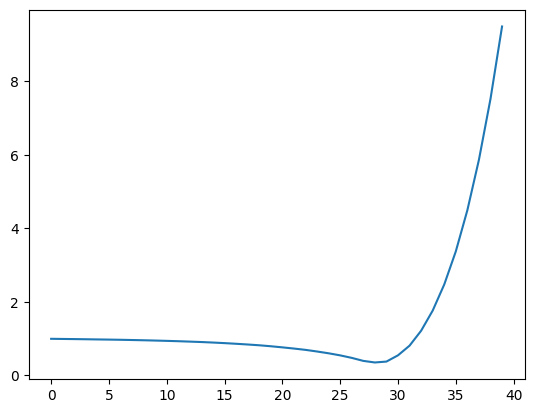

In [9]:
tensor_shape = (90, 100, 105)
tucker_rank = (32, 30, 28)
B, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

factor_matrices, core_tensor, final_rank, errors = gta(B, max_rank=100, max_iter_als=100, error_tol=0.01)


print("Размеры матриц:")
for i, u_matrix in enumerate(factor_matrices):
    print(f"  U[{i}]: {u_matrix.shape}")
print(f"Размер ядра: {core_tensor.shape}")

reconstructed_B = multi_mode_dot(core_tensor, factor_matrices)
final_error_check = torch.norm(B - reconstructed_B) / torch.norm(B)
print(f"Итоговая ошибка: {final_error_check.item():.6f}")


x = list(range(0, len(errors[:40])))
plt.plot(x, errors[:40])
plt.show()

Размеры матриц:
  U[0]: torch.Size([90, 100])
  U[1]: torch.Size([100, 100])
  U[2]: torch.Size([105, 100])
Размер ядра: torch.Size([100, 100, 100])
Итоговая ошибка: 5511.134277


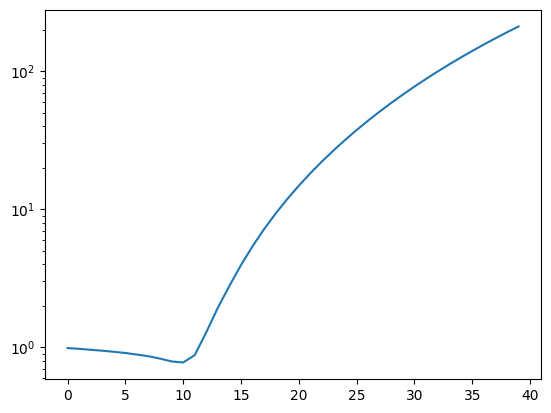

In [10]:
tensor_shape = (90, 100, 105)
tucker_rank = (42, 11, 10)
B, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

factor_matrices, core_tensor, final_rank, errors = gta(B, max_rank=100, max_iter_als=100, error_tol=0.01)


print("Размеры матриц:")
for i, u_matrix in enumerate(factor_matrices):
    print(f"  U[{i}]: {u_matrix.shape}")
print(f"Размер ядра: {core_tensor.shape}")

reconstructed_B = multi_mode_dot(core_tensor, factor_matrices)
final_error_check = torch.norm(B - reconstructed_B) / torch.norm(B)
print(f"Итоговая ошибка: {final_error_check.item():.6f}")


x = list(range(0, len(errors[:40])))
plt.plot(x, errors[:40])
plt.yscale('log')
plt.show()

In [11]:
tensor_shape = (90, 200, 105)
tucker_rank = (42, 12, 10)
B, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)


estimated_core_dims = []
for k in range(B.dim()):
    B_k_unfolded = tensorly.unfold(B, k)
    _, _, rank_k, _ = gta(B_k_unfolded, error_tol=0.005, max_rank=max(B_k_unfolded.shape))
    estimated_core_dims.append(rank_k)
print(f"Оцененный ранг: {estimated_core_dims}")

Оцененный ранг: [42, 12, 10]


3. Добавка шума

tensor(163.5140) tensor(163.2277)
Размеры матриц:
  U[0]: torch.Size([90, 100])
  U[1]: torch.Size([100, 100])
  U[2]: torch.Size([105, 100])
Размер ядра: torch.Size([100, 100, 100])
Итоговая ошибка: 0.639937


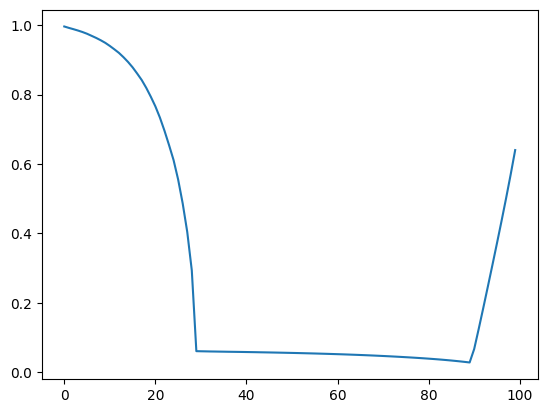

In [12]:
tensor_shape = (90, 100, 105)
tucker_rank = (30, 30, 30)
B_, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

B = B_ + 0.01 * torch.randn_like(B_)
print(torch.norm(B), torch.norm(B_))

factor_matrices, core_tensor, final_rank, errors = gta(B, max_rank=100, max_iter_als=100, error_tol=0.01)


print("Размеры матриц:")
for i, u_matrix in enumerate(factor_matrices):
    print(f"  U[{i}]: {u_matrix.shape}")
print(f"Размер ядра: {core_tensor.shape}")

reconstructed_B = multi_mode_dot(core_tensor, factor_matrices)
final_error_check = torch.norm(B - reconstructed_B) / torch.norm(B)
print(f"Итоговая ошибка: {final_error_check.item():.6f}")


x = list(range(0, len(errors[:100])))
plt.plot(x, errors[:100])
plt.show()



tensor(169.2458) tensor(162.1051)
Размеры матриц:
  U[0]: torch.Size([90, 100])
  U[1]: torch.Size([100, 100])
  U[2]: torch.Size([105, 100])
Размер ядра: torch.Size([100, 100, 100])
Итоговая ошибка: 0.489215


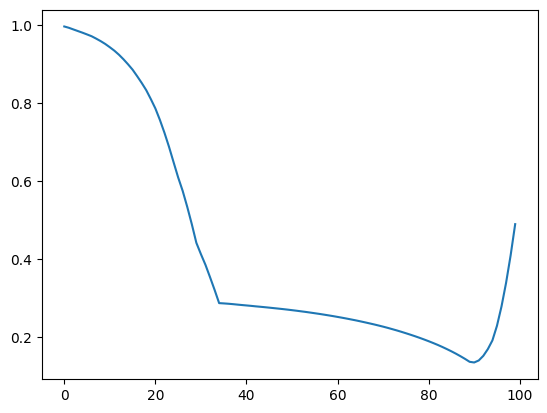

In [13]:
tensor_shape = (90, 100, 105)
tucker_rank = (35, 30, 25)
B_, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

B = B_ + 0.05 * torch.randn_like(B_)
print(torch.norm(B), torch.norm(B_))

factor_matrices, core_tensor, final_rank, errors = gta(B, max_rank=100, max_iter_als=100, error_tol=0.01)


print("Размеры матриц:")
for i, u_matrix in enumerate(factor_matrices):
    print(f"  U[{i}]: {u_matrix.shape}")
print(f"Размер ядра: {core_tensor.shape}")

reconstructed_B = multi_mode_dot(core_tensor, factor_matrices)
final_error_check = torch.norm(B - reconstructed_B) / torch.norm(B)
print(f"Итоговая ошибка: {final_error_check.item():.6f}")


x = list(range(0, len(errors[:100])))
plt.plot(x, errors[:100])
plt.show()

tensor(226.6859) tensor(221.3669)
Размеры матриц:
  U[0]: torch.Size([90, 100])
  U[1]: torch.Size([100, 100])
  U[2]: torch.Size([105, 100])
Размер ядра: torch.Size([100, 100, 100])
Итоговая ошибка: 0.474327


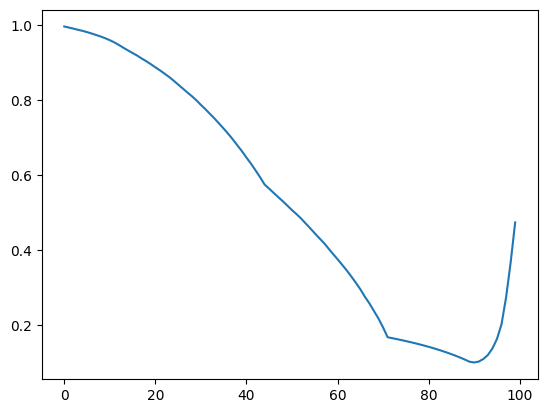

In [14]:
tensor_shape = (90, 100, 105)
tucker_rank = (45, 15, 72)
B_, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

B = B_ + 0.05 * torch.randn_like(B_)
print(torch.norm(B), torch.norm(B_))

factor_matrices, core_tensor, final_rank, errors = gta(B, max_rank=100, max_iter_als=100, error_tol=0.01)


print("Размеры матриц:")
for i, u_matrix in enumerate(factor_matrices):
    print(f"  U[{i}]: {u_matrix.shape}")
print(f"Размер ядра: {core_tensor.shape}")

reconstructed_B = multi_mode_dot(core_tensor, factor_matrices)
final_error_check = torch.norm(B - reconstructed_B) / torch.norm(B)
print(f"Итоговая ошибка: {final_error_check.item():.6f}")


x = list(range(0, len(errors[:100])))
plt.plot(x, errors[:100])
plt.show()

#### Эксперименты с GTA для анфолдингов тензоров по всем модам

1. без шума

In [ ]:
tensor_shape = (90, 200, 105)
tucker_rank = (42, 12, 70)
B, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)


estimated_core_dims = []
for k in range(B.dim()):
    B_k_unfolded = tensorly.unfold(B, k)
    print(B_k_unfolded.shape)
    _, _, rank_k, _ = gta(B_k_unfolded, error_tol=0.005, max_rank=max(B_k_unfolded.shape))
    estimated_core_dims.append(rank_k)
print(f"Оцененный ранг: {estimated_core_dims}")

torch.Size([90, 21000])
torch.Size([200, 9450])
torch.Size([105, 18000])


KeyboardInterrupt: 

2. с шумом

tensor(241.3301) tensor(221.1031)
Оцененный ранг: [84, 93, 98]


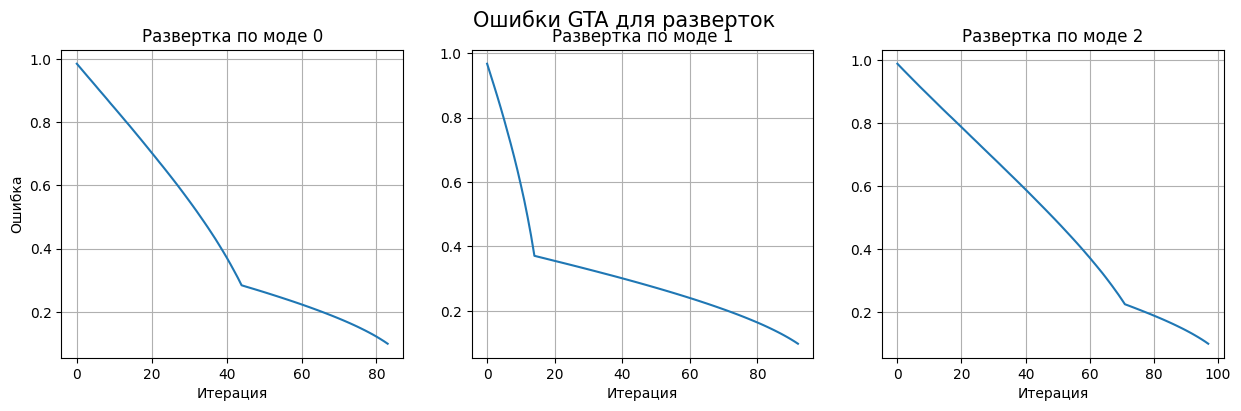

In [ ]:
tensor_shape = (90, 100, 105)
tucker_rank = (45, 15, 72)
B_, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

B = B_ + 0.1 * torch.randn_like(B_)
print(torch.norm(B), torch.norm(B_))


n_modes = B.dim()
fig, axes = plt.subplots(nrows=1, ncols=n_modes, figsize=(5 * n_modes, 4))
if n_modes == 1:
    axes = [axes]
fig.suptitle('Ошибки GTA для разверток', fontsize=15)

estimated_core_dims = []
for k in range(B.dim()):
    B_k_unfolded = tensorly.unfold(B, k)
    _, _, rank_k, errors = gta(B_k_unfolded, error_tol=0.1, max_rank=max(B_k_unfolded.shape))
    
    # 2. Выбираем k-тую ось (ax) из массива осей для рисования
    ax = axes[k]
    
    # 3. Рисуем график на выбранной оси
    x = list(range(len(errors[:100])))
    ax.plot(x, errors[:100])
    
    # Настраиваем подписи для каждого отдельного графика
    ax.set_title(f'Развертка по моде {k}')
    ax.set_xlabel('Итерация')
    ax.grid(True)
    # Добавляем подпись оси Y только для самого левого графика для чистоты
    if k == 0:
        ax.set_ylabel('Ошибка')

    estimated_core_dims.append(rank_k)
print(f"Оцененный ранг: {estimated_core_dims}")

Такой излом графка наверняка можно отловить каким-нибудь вероятностным критерием

# **Адаптация алгоритмов для матриц**


In [ ]:

def rank1_approx(B: torch.Tensor, max_iter: int = 100, tol: float = 1e-6, device: torch.device = None) -> tuple[float, list[torch.Tensor]]:

    m, n = B.shape

    if device is None:
        device = B.device
    
    if B.dim() != 2:
        raise ValueError("Input must be a 2D matrix.")
    
    # Инициализируем v случайным единичным вектором
    v = torch.randn(n, device=device, dtype=B.dtype)
    v = v / torch.norm(v)

    for _ in range(max_iter):
        v_old = v.clone()

        u = B @ v
        norm_u = torch.norm(u)
        if norm_u > 0:
            u = u / norm_u

        v = B.T @ u
        sigma = torch.norm(v) # Эта норма и есть главное сингулярное число
        if sigma > 0:
            v = v / sigma
            
        if torch.norm(v - v_old) < tol:
            break
        
    return sigma, u, v

In [ ]:
import time
def gta_matrix( B: torch.Tensor, 
        error_tol: float = 1e-4, 
        max_rank: int = 50, 
        max_iter_als: int = 100, 
        tol_als: float = 1e-5,
        device: torch.device = None, 
        verbose: bool = True
        ) -> tuple[list[torch.Tensor], torch.Tensor, int]:
    
    # Общая засечка времени
    time_total_start = time.time()
    timings = {}
    
    # === ИНИЦИАЛИЗАЦИЯ ===
    time_init_start = time.time() #засекаем время инициализации

    # Определяем девайс
    if device is None:
        device = B.device
    
    # Проверяем корректность входных данных
    if B.dim() != 2:
        raise ValueError("Input must be a 2D matrix.")

    # Перемещаем матрицу на нужный девайс и клонируем её
    B = B.to(device)
    B_residual = B.clone()
    norm_B = torch.norm(B)
    
    if norm_B == 0:
        return [torch.tensor([], device=device), torch.tensor([], device=device)], \
               torch.zeros_like(B), 0, [0.0]

    U_factors, V_factors, Sigma_values = [], [], []
    errors = []

    time_init = time.time() - time_init_start
    timings['initialization'] = time_init
    

    # === ОСНОВНОЙ ЦИКЛ ===
    timings['rank1_approximations'] = []  # Время для каждой одноранговой аппроксимации
    timings['orthogonalization'] = []     # Время для ортогонализации
    timings['deflation'] = []             # Время для вычитания приближения
    timings['error_computation'] = []     # Время для вычисления ошибки

    for r in range(max_rank):
        # Находим лучшее одноранговое приближение для текущего остатка
        time_r1_start = time.time()

        sigma, u, v = rank1_approx(B_residual, max_iter=max_iter_als, tol=tol_als, device=device)
        # print(r, "r1 - approx done")

        time_r1 = time.time() - time_r1_start
        timings['rank1_approximations'].append(time_r1)

        # Ортогонализуем
        time_ortho_start = time.time()

        for _ in range(2): 
            for prev_u in U_factors:
                u = u - torch.dot(u, prev_u) * prev_u
            norm_u = torch.norm(u)
            if norm_u > 0:
                u = u / norm_u

        for _ in range(2):
            for prev_v in V_factors:
                v = v - torch.dot(v, prev_v) * prev_v
            norm_v = torch.norm(v)
            if norm_v > 0:
                v = v / norm_v
        
        time_ortho = time.time() - time_ortho_start
        timings['orthogonalization'].append(time_ortho)

        # Сохраняем
        U_factors.append(u)
        V_factors.append(v)
        Sigma_values.append(sigma.item() if sigma.is_cuda else sigma.item())

        # Вычитаем найденное приближение из остатка
        time_defl_start = time.time()

        rank_1_approx = sigma * torch.outer(u, v)
        B_residual -= rank_1_approx

        time_defl = time.time() - time_defl_start
        timings['deflation'].append(time_defl)


        # Считаем относительную ошибку
        time_err_start = time.time()

        current_error = torch.norm(B_residual) / norm_B
        errors.append(current_error.item())
        
        time_err = time.time() - time_err_start
        timings['error_computation'].append(time_err)

        # Проверка условия остановки
        if current_error < error_tol:
            break
    
    # === ЭТАП: Финализация и восстановление ===
    time_final_start = time.time()

    #Если ранг нулевой,  возвращаем пустые
    final_rank = len(Sigma_values)
    if final_rank == 0:
        return [torch.tensor([], device=device), torch.tensor([], device=device)], \
               torch.zeros_like(B), 0, errors

    # Стэкуем векторы в матрицы
    U = torch.stack(U_factors, dim=1)
    V = torch.stack(V_factors, dim=1)
    S = torch.tensor(Sigma_values, device=device, dtype=B.dtype)
    
    # Восстанавливаем итоговое приближение
    B_approx = U @ torch.diag(S) @ V.T

    time_final = time.time() - time_final_start
    timings['finalization'] = time_final

     # === ОБЩЕЕ ВРЕМЯ ===
    time_total = time.time() - time_total_start
    timings['total'] = time_total
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"ОТЧЕТ О ВРЕМЕНИ ВЫПОЛНЕНИЯ GTA")
        print(f"{'='*60}")
        print(f"Найденный ранг: {final_rank}")
        print(f"Итоговая ошибка: {errors[-1]:.6e}")
        print(f"\nВремя по этапам:")
        print(f"  Инициализация:           {timings['initialization']:.4f}s")
        print(f"  Поиск ранга-1 (всего):   {sum(timings['rank1_approximations']):.4f}s "
              f"(среднее: {sum(timings['rank1_approximations'])/len(timings['rank1_approximations']):.4f}s)")
        print(f"  Ортогонализация (всего): {sum(timings['orthogonalization']):.4f}s "
              f"(среднее: {sum(timings['orthogonalization'])/len(timings['orthogonalization']):.4f}s)")
        print(f"  Дефляция (всего):        {sum(timings['deflation']):.4f}s "
              f"(среднее: {sum(timings['deflation'])/len(timings['deflation']):.4f}s)")
        print(f"  Вычисление ошибки:       {sum(timings['error_computation']):.4f}s "
              f"(среднее: {sum(timings['error_computation'])/len(timings['error_computation']):.4f}s)")
        print(f"  Финализация:             {timings['finalization']:.4f}s")
        print(f"\n  ИТОГО:                   {time_total:.4f}s")
        print(f"{'='*60}\n")

    return [U, V], B_approx, final_rank, errors

#### Тестирование матричных вариантов


ИТОГОВЫЙ ОТЧЕТ О ВРЕМЕНИ ВЫПОЛНЕНИЯ
Найденный ранг: 45
Итоговая ошибка: 5.530338e-03

Время по этапам:
  Инициализация:           0.0029s
  Поиск ранга-1 (всего):   5.0860s (среднее: 0.1130s)
  Ортогонализация (всего): 0.0694s (среднее: 0.0015s)
  Дефляция (всего):        0.1442s (среднее: 0.0032s)
  Вычисление ошибки:       0.0309s (среднее: 0.0007s)
  Финализация:             0.0063s

  ИТОГО:                   5.3423s


ИТОГОВЫЙ ОТЧЕТ О ВРЕМЕНИ ВЫПОЛНЕНИЯ
Найденный ранг: 15
Итоговая ошибка: 4.411057e-03

Время по этапам:
  Инициализация:           0.0026s
  Поиск ранга-1 (всего):   1.6271s (среднее: 0.1085s)
  Ортогонализация (всего): 0.0082s (среднее: 0.0005s)
  Дефляция (всего):        0.0495s (среднее: 0.0033s)
  Вычисление ошибки:       0.0101s (среднее: 0.0007s)
  Финализация:             0.0035s

  ИТОГО:                   1.7019s


ИТОГОВЫЙ ОТЧЕТ О ВРЕМЕНИ ВЫПОЛНЕНИЯ
Найденный ранг: 72
Итоговая ошибка: 4.592667e-03

Время по этапам:
  Инициализация:           0.0020s
  Поиск

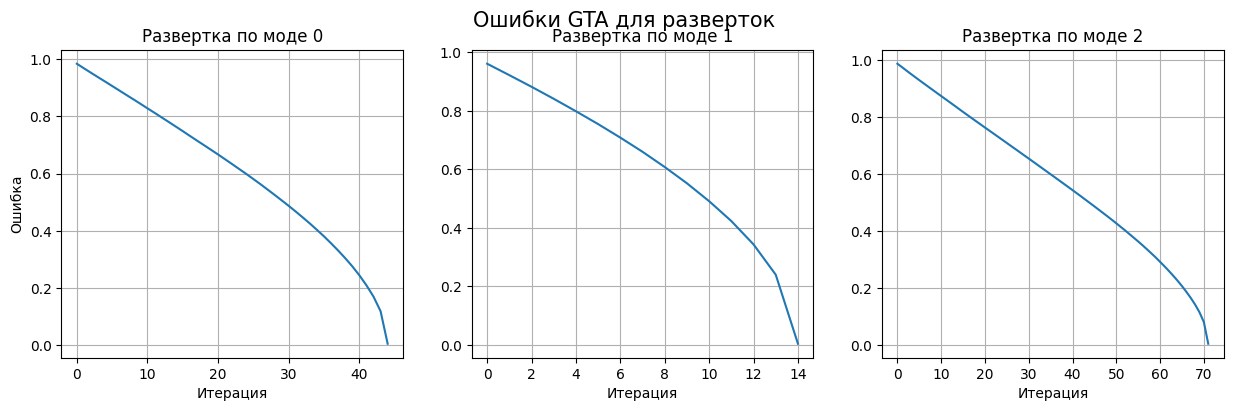

In [ ]:
tensor_shape = (128, 128, 128)
tucker_rank = (45, 15, 72)
B, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)


n_modes = B.dim()
fig, axes = plt.subplots(nrows=1, ncols=n_modes, figsize=(5 * n_modes, 4))
if n_modes == 1:
    axes = [axes]
fig.suptitle('Ошибки GTA для разверток', fontsize=15)

estimated_core_dims = []
for k in range(B.dim()):
    B_k_unfolded = tensorly.unfold(B, k)
    _, B_approx, rank_k, errors = gta_matrix(B_k_unfolded, error_tol=0.01, max_rank=max(B_k_unfolded.shape))
    
    ax = axes[k]
    x = list(range(len(errors[:100])))
    ax.plot(x, errors[:100])
    ax.set_title(f'Развертка по моде {k}')
    ax.set_xlabel('Итерация')
    ax.grid(True)
    if k == 0:
        ax.set_ylabel('Ошибка')

    estimated_core_dims.append(rank_k)
print(f"Оцененный ранг: {estimated_core_dims}")

С шумом


ИТОГОВЫЙ ОТЧЕТ О ВРЕМЕНИ ВЫПОЛНЕНИЯ
Найденный ранг: 128
Итоговая ошибка: 5.519111e-03

Время по этапам:
  Инициализация:           0.0023s
  Поиск ранга-1 (всего):   14.6864s (среднее: 0.1147s)
  Ортогонализация (всего): 0.5663s (среднее: 0.0044s)
  Дефляция (всего):        0.3879s (среднее: 0.0030s)
  Вычисление ошибки:       0.0891s (среднее: 0.0007s)
  Финализация:             0.0193s

  ИТОГО:                   15.7595s



KeyboardInterrupt: 

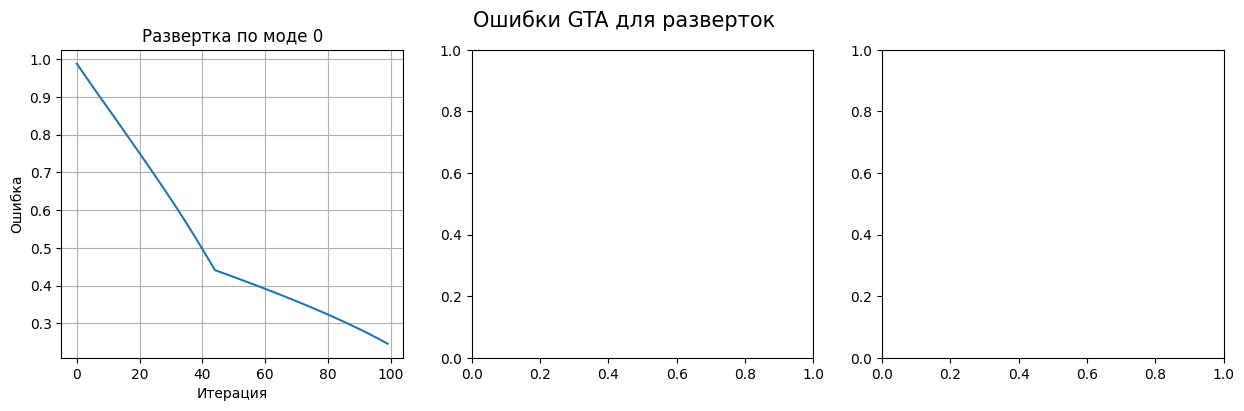

In [ ]:
tensor_shape = (128, 128, 128)
tucker_rank = (45, 15, 72)
B_, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

B = B_ + 0.1 * torch.randn_like(B_)
# print(torch.norm(B), torch.norm(B_))


n_modes = B.dim()
fig, axes = plt.subplots(nrows=1, ncols=n_modes, figsize=(5 * n_modes, 4))
if n_modes == 1:
    axes = [axes]
fig.suptitle('Ошибки GTA для разверток', fontsize=15)

estimated_core_dims = []
for k in range(B.dim()):
    B_k_unfolded = tensorly.unfold(B, k)
    _, B_approx, rank_k, errors = gta_matrix(B_k_unfolded, error_tol=0.01, max_iter_als=100, max_rank=max(B_k_unfolded.shape))
    
    ax = axes[k]
    x = list(range(len(errors[:100])))
    ax.plot(x, errors[:100])
    ax.set_title(f'Развертка по моде {k}')
    ax.set_xlabel('Итерация')
    ax.grid(True)
    if k == 0:
        ax.set_ylabel('Ошибка')

    estimated_core_dims.append(rank_k)
print(f"Оцененный ранг: {estimated_core_dims}")

#### Сравнительный анализ с SVD и scipy.linalg.svd

In [ ]:
def hosvd_gta(tensor, error_tol=1e-4):
    """HOSVD с использованием gta_matrix для SVD разложения анфолдингов."""
    factors = []
    for k in range(tensor.dim()):
        unfolding = tensorly.unfold(tensor, k)
        # Из gta_matrix нам нужна только матрица U (левые сингулярные векторы)
        UV, _, _, errors = gta_matrix(unfolding, error_tol=error_tol, max_rank=max(unfolding.shape))
        U = UV[0]
        factors.append(U)
    # Ядро вычисляется проекцией исходного тензора на пространство факторов
    core = multi_mode_dot(tensor, [f.T for f in factors])
    return core, factors

In [ ]:
import scipy
import numpy as np
tensor_shape = (100, 100, 100)
tucker_rank = (10, 15, 20)
error_tol = 0.1



test_tensor, _, _ = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)
print(f"Сгенерирован тестовый тензор формы {tensor_shape} с рангом Такера {tucker_rank}\n")
unfolding = tensorly.unfold(test_tensor, 2)
print(f"Shape: {unfolding.shape}")

# Измерение времени выполнения GTA
start_time_gta = time.time()
UV, approx_unfolding, _, errors = gta_matrix(unfolding, error_tol=error_tol, tol_als = 1e-15, max_rank=max(unfolding.shape))
duration_gta = time.time() - start_time_gta
print(f"Время выполнения GTA: {duration_gta:.4f}c\n")
print(f"Относительная ошибка разложения: {np.linalg.norm(approx_unfolding - unfolding) / np.linalg.norm(unfolding)}")

# Измерение времени выполнения scipy.linalg.svd
start_time_svd = time.time()
U, s, Vh = np.linalg.svd(unfolding, full_matrices=False)
duration_svd = time.time() - start_time_svd
print(f"Время выполнения SVD: {duration_svd:.4f}c\n")






Сгенерирован тестовый тензор формы (100, 100, 100) с рангом Такера (10, 15, 20)

Shape: torch.Size([100, 10000])

ОТЧЕТ О ВРЕМЕНИ ВЫПОЛНЕНИЯ GTA
Найденный ранг: 20
Итоговая ошибка: 1.329911e-03

Время по этапам:
  Инициализация:           0.0013s
  Поиск ранга-1 (всего):   1.0237s (среднее: 0.0512s)
  Ортогонализация (всего): 0.0300s (среднее: 0.0015s)
  Дефляция (всего):        0.0193s (среднее: 0.0010s)
  Вычисление ошибки:       0.0057s (среднее: 0.0003s)
  Финализация:             0.0022s

  ИТОГО:                   1.0833s

Время выполнения GTA: 1.0846c

Относительная ошибка разложения: 0.001329911407083273
Время выполнения SVD: 0.1636c

